In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import skspatial.objects as so
import sys
import os

In [2]:
import sys, os
sys.path.append(os.path.abspath("../turb_template"))
import units_cool as un
from units import pressure, mu, KELVIN, CONST_kB, CONST_amu, unit_q, unit_time, unit_density, unit_length

In [3]:
import importlib.util

def load_v_turb(path_to_input_py):
    spec = importlib.util.spec_from_file_location("input_module", path_to_input_py)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.v_turb



In [5]:
vt_034 = load_v_turb("/ptmp/mpa/ankitad/athenapk/gnat_0.34/input_cool.py")
vt_107 = load_v_turb("/ptmp/mpa/ankitad/athenapk/gnat_1.7/input_cool.py")
vt_304 = load_v_turb("/ptmp/mpa/ankitad/athenapk/gnat_3.4/input_cool.py")
vt_5 = load_v_turb("/ptmp/mpa/ankitad/athenapk/gnat_5.15/input_cool.py")
vt_805 = load_v_turb("/ptmp/mpa/ankitad/athenapk/gnat_8.5/input_cool.py")

'''
vt_906 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_9.6/input_cool.py")
vt_14 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_14/input_cool.py")
vt_17 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_17/input_cool.py")
vt_20 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_20/input_cool.py")
vt_24 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_24/input_cool.py")
'''
#v_TEST = load_v_turb("/ptmp/mpa/ankitad/athenapk/TEST/input_cool.py")
#v_turb_09 = load_v_turb("/ptmp/mpa/ankitad/athenapk/nc_256_09/input.py")

new ratio = 1.71813731678919e-07
new ratio = 1.71813731678919e-07
new ratio = 1.71813731678919e-07
new ratio = 1.71813731678919e-07
new ratio = 1.71813731678919e-07


'\nvt_906 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_9.6/input_cool.py")\nvt_14 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_14/input_cool.py")\nvt_17 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_17/input_cool.py")\nvt_20 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_20/input_cool.py")\nvt_24 = load_v_turb("/ptmp/mpa/ankitad/athenapk/test_05_24/input_cool.py")\n'

# Reading and Loading

In [33]:
hst_file = [
    "/ptmp/mpa/ankitad/athenapk/gnat_0.34/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/gnat_1.7/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/gnat_3.4/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/gnat_5.15/parthenon.out1.hst",
    "/ptmp/mpa/ankitad/athenapk/gnat_8.5/parthenon.out1.hst"
    #"/ptmp/mpa/ankitad/athenapk/test_05_0.24/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_1.2/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_2.4/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_4.8/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_5.5/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_9.6/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_14/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_17/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_20/parthenon.out1.hst",
    #"/ptmp/mpa/ankitad/athenapk/test_05_24/parthenon.out1.hst"
    #"/ptmp/mpa/ankitad/athenapk/TEST/parthenon.out1.hst"

]

files = [
    "/ptmp/mpa/ankitad/athenapk/gnat_0.34/parthenon.prim.00037.phdf",
    "/ptmp/mpa/ankitad/athenapk/gnat_1.7/parthenon.prim.00066.phdf"
]

In [7]:
def read_hdf5(filename):
    with h5py.File(filename, "r") as f:
        print(f"Keys: {f.keys()} \n")
        print(f"Attributes: {f.attrs.keys()} \n")

        prim = f["prim"][()]
        rho = prim[:, 0]
        prs = prim[:, 4]  
        
        # vel1 = prim[1]
        # vel2 = prim[2]
        # vel3 = prim[3]

        # x1 = f["x1v"][()]
        # x2 = f["x2v"][()]
        # x3 = f["x3v"][()]

        LogicalLocations = f["LogicalLocations"][()]
        MeshBlockSize = np.array(rho.shape[1:4])     # auto-detect 
        NumMeshBlocks = rho.shape[0]
        RootGridSize = np.array([128, 128, 128])
    
        print("np.shape(LogicalLocations) =", np.shape(LogicalLocations))
        print("np.shape(rho) =", np.shape(rho))
        print("RootGridSize =", RootGridSize)
        print("NumMeshBlocks =", NumMeshBlocks)
        print("LogicalLocations[10] =", LogicalLocations[5])

        # print(f"{np.shape(x1) = }")
        # print(f"{np.shape(x2) = }")
        # print(f"{np.shape(x3) = }\n")
        
    #print(f"{LogicalLocations[10] = }")

    rho_full = np.zeros(tuple(RootGridSize), dtype=float)
    prs_full = np.zeros(tuple(RootGridSize), dtype=float)

    # x1_full = np.zeros(np.product(np.shape(x1)), dtype=float)
    # x2_full = np.zeros(np.product(np.shape(x2)), dtype=float)
    # x3_full = np.zeros(np.product(np.shape(x3)), dtype=float)

    for i in range(NumMeshBlocks):
        start1 = MeshBlockSize[0] * LogicalLocations[i][0]
        end1 = start1 + MeshBlockSize[0]

        start2 = MeshBlockSize[1] * LogicalLocations[i][1]
        end2 = start2 + MeshBlockSize[1]

        start3 = MeshBlockSize[2] * LogicalLocations[i][2]
        end3 = start3 + MeshBlockSize[2]

        rho_full[start3:end3, start2:end2, start1:end1] = rho[i]

        prs_full[start3:end3, start2:end2, start1:end1] = prs[i]

    #     x1_full[start1:end1] = x1[i]
    #     x2_full[start2:end2] = x2[i]
    #     x3_full[start3:end3] = x3[i]

    # T = prs_full / rho_full

    return rho_full, prs_full

In [8]:
def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

def read_hst_rst(filename):
    headers = [
        "time", "dt", "cycle", "nbtotal", "mass",
        "1-mom", "2-mom", "3-mom", "KE", "tot-E",
        "Ms", "DeltaEcool"
    ]
    
    data = np.loadtxt(filename)
    return headers, data


In [34]:
# Call the data loader
rho_full_01, prs_full_01 = read_hdf5(files[0])
rho_full_03, prs_full_03 = read_hdf5(files[1])
'''
rho_full_05, prs_full_05 = read_hdf5(files[2])
rho_full_07, prs_full_07 = read_hdf5(files[3])
rho_full_14, prs_full_14 = read_hdf5(files[4])
rho_full_5, prs_full_5 = read_hdf5(files[5])
rho_full_9, prs_full_9 = read_hdf5(files[6])
rho_full_24, prs_full_24 = read_hdf5(files[7])
'''

Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 32, 32, 32)
RootGridSize = [128 128 128]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 32, 32, 32)
RootGridSize = [128 128 128]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]


'\nrho_full_05, prs_full_05 = read_hdf5(files[2])\nrho_full_07, prs_full_07 = read_hdf5(files[3])\nrho_full_14, prs_full_14 = read_hdf5(files[4])\nrho_full_5, prs_full_5 = read_hdf5(files[5])\nrho_full_9, prs_full_9 = read_hdf5(files[6])\nrho_full_24, prs_full_24 = read_hdf5(files[7])\n'

In [59]:
# headers
headers_024, data_024 = read_hst_rst(hst_file[0])
headers_102, data_102 = read_hst_rst(hst_file[1])
#headers_408, data_408 = read_hst_rst(hst_file[3])
'''
headers_5, data_5 = read_hst_rst(hst_file[4])
headers_9, data_9 = read_hst_rst(hst_file[5])
headers_14, data_14 = read_hst_rst(hst_file[6])
headers_17, data_17 = read_hst_rst(hst_file[7])
headers_20, data_20 = read_hst_rst(hst_file[8])
headers_24, data_24 = read_hst_rst(hst_file[9])
'''

'\nheaders_5, data_5 = read_hst_rst(hst_file[4])\nheaders_9, data_9 = read_hst_rst(hst_file[5])\nheaders_14, data_14 = read_hst_rst(hst_file[6])\nheaders_17, data_17 = read_hst_rst(hst_file[7])\nheaders_20, data_20 = read_hst_rst(hst_file[8])\nheaders_24, data_24 = read_hst_rst(hst_file[9])\n'

In [60]:
# Index mapping

time_idx_024 = headers_024.index("time")
mass_idx_024 = headers_024.index("mass")
ke_idx_024   = headers_024.index("KE")
etot_idx_024 = headers_024.index("tot-E")

time_idx_102 = headers_102.index("time")
mass_idx_102 = headers_102.index("mass")
ke_idx_102   = headers_102.index("KE")
etot_idx_102 = headers_102.index("tot-E")

'''
time_idx_204 = headers_204.index("time")
mass_idx_204 = headers_204.index("mass")
ke_idx_204   = headers_204.index("KE")
etot_idx_204 = headers_204.index("tot-E")

time_idx_408 = headers_408.index("time")
mass_idx_408 = headers_408.index("mass")
ke_idx_408   = headers_408.index("KE")
etot_idx_408 = headers_408.index("tot-E")

time_idx_5 = headers_5.index("time")
mass_idx_5 = headers_5.index("mass")
ke_idx_5   = headers_5.index("KE")
etot_idx_5 = headers_5.index("tot-E")

time_idx_9 = headers_9.index("time")
mass_idx_9 = headers_9.index("mass")
ke_idx_9   = headers_9.index("KE")
etot_idx_9 = headers_9.index("tot-E")

time_idx_14 = headers_14.index("time")
mass_idx_14 = headers_14.index("mass")
ke_idx_14   = headers_14.index("KE")
etot_idx_14 = headers_14.index("tot-E")

time_idx_17 = headers_17.index("time")
mass_idx_17 = headers_17.index("mass")
ke_idx_17   = headers_17.index("KE")
etot_idx_17 = headers_17.index("tot-E")

time_idx_20 = headers_20.index("time")
mass_idx_20 = headers_20.index("mass")
ke_idx_20   = headers_20.index("KE")
etot_idx_20 = headers_20.index("tot-E")

time_idx_24 = headers_24.index("time")
mass_idx_24 = headers_24.index("mass")
ke_idx_24   = headers_24.index("KE")
etot_idx_24 = headers_24.index("tot-E")
'''

'\ntime_idx_204 = headers_204.index("time")\nmass_idx_204 = headers_204.index("mass")\nke_idx_204   = headers_204.index("KE")\netot_idx_204 = headers_204.index("tot-E")\n\ntime_idx_408 = headers_408.index("time")\nmass_idx_408 = headers_408.index("mass")\nke_idx_408   = headers_408.index("KE")\netot_idx_408 = headers_408.index("tot-E")\n\ntime_idx_5 = headers_5.index("time")\nmass_idx_5 = headers_5.index("mass")\nke_idx_5   = headers_5.index("KE")\netot_idx_5 = headers_5.index("tot-E")\n\ntime_idx_9 = headers_9.index("time")\nmass_idx_9 = headers_9.index("mass")\nke_idx_9   = headers_9.index("KE")\netot_idx_9 = headers_9.index("tot-E")\n\ntime_idx_14 = headers_14.index("time")\nmass_idx_14 = headers_14.index("mass")\nke_idx_14   = headers_14.index("KE")\netot_idx_14 = headers_14.index("tot-E")\n\ntime_idx_17 = headers_17.index("time")\nmass_idx_17 = headers_17.index("mass")\nke_idx_17   = headers_17.index("KE")\netot_idx_17 = headers_17.index("tot-E")\n\ntime_idx_20 = headers_20.index(

In [61]:
# data extraction

time_024 = data_024[:, time_idx_024]
mass_024 = data_024[:, mass_idx_024]
KE_024   = data_024[:, ke_idx_024]
Etot_024 = data_024[:, etot_idx_024]

time_102 = data_102[:, time_idx_102]
mass_102 = data_102[:, mass_idx_102]
KE_102   = data_102[:, ke_idx_102]
Etot_102 = data_102[:, etot_idx_102]

'''
time_204 = data_204[:, time_idx_204]
mass_204 = data_204[:, mass_idx_204]
KE_204   = data_204[:, ke_idx_204]
Etot_204 = data_204[:, etot_idx_204]

time_408 = data_408[:, time_idx_408]
mass_408 = data_408[:, mass_idx_408]
KE_408   = data_408[:, ke_idx_408]
Etot_408 = data_408[:, etot_idx_408]

time_5 = data_5[:, time_idx_5]
mass_5 = data_5[:, mass_idx_5]
KE_5   = data_5[:, ke_idx_5]
Etot_5 = data_5[:, etot_idx_5]

time_9 = data_9[:, time_idx_9]
mass_9 = data_9[:, mass_idx_9]
KE_9   = data_9[:, ke_idx_9]
Etot_9 = data_9[:, etot_idx_9]

time_14 = data_14[:, time_idx_14]
mass_14 = data_14[:, mass_idx_14]
KE_14   = data_14[:, ke_idx_14]
Etot_14 = data_14[:, etot_idx_14]

time_17 = data_17[:, time_idx_17]
mass_17 = data_17[:, mass_idx_17]
KE_17   = data_17[:, ke_idx_17]
Etot_17 = data_17[:, etot_idx_17]

time_20 = data_20[:, time_idx_20]
mass_20 = data_20[:, mass_idx_20]
KE_20   = data_20[:, ke_idx_20]
Etot_20 = data_20[:, etot_idx_20]

time_24 = data_24[:, time_idx_24]
mass_24 = data_24[:, mass_idx_24]
KE_24   = data_24[:, ke_idx_24]
Etot_24 = data_24[:, etot_idx_24]
'''

'\ntime_204 = data_204[:, time_idx_204]\nmass_204 = data_204[:, mass_idx_204]\nKE_204   = data_204[:, ke_idx_204]\nEtot_204 = data_204[:, etot_idx_204]\n\ntime_408 = data_408[:, time_idx_408]\nmass_408 = data_408[:, mass_idx_408]\nKE_408   = data_408[:, ke_idx_408]\nEtot_408 = data_408[:, etot_idx_408]\n\ntime_5 = data_5[:, time_idx_5]\nmass_5 = data_5[:, mass_idx_5]\nKE_5   = data_5[:, ke_idx_5]\nEtot_5 = data_5[:, etot_idx_5]\n\ntime_9 = data_9[:, time_idx_9]\nmass_9 = data_9[:, mass_idx_9]\nKE_9   = data_9[:, ke_idx_9]\nEtot_9 = data_9[:, etot_idx_9]\n\ntime_14 = data_14[:, time_idx_14]\nmass_14 = data_14[:, mass_idx_14]\nKE_14   = data_14[:, ke_idx_14]\nEtot_14 = data_14[:, etot_idx_14]\n\ntime_17 = data_17[:, time_idx_17]\nmass_17 = data_17[:, mass_idx_17]\nKE_17   = data_17[:, ke_idx_17]\nEtot_17 = data_17[:, etot_idx_17]\n\ntime_20 = data_20[:, time_idx_20]\nmass_20 = data_20[:, mass_idx_20]\nKE_20   = data_20[:, ke_idx_20]\nEtot_20 = data_20[:, etot_idx_20]\n\ntime_24 = data_24

In [44]:
headers_TEST, data_TEST = read_hst_rst(hst_file[8])

time_idx_TEST = headers_TEST.index("time")
mass_idx_TEST = headers_TEST.index("mass")
ke_idx_TEST   = headers_TEST.index("KE")
etot_idx_TEST = headers_TEST.index("tot-E")

time_TEST = data_TEST[:, time_idx_TEST]
mass_TEST = data_TEST[:, mass_idx_TEST]
KE_TEST   = data_TEST[:, ke_idx_TEST]
Etot_TEST = data_TEST[:, etot_idx_TEST]

# Slices

In [13]:
# Visualize a midplane slice
def show_midplane_slice(data, label):

    plt.imshow(data[:, :, data.shape[2] // 2], origin='lower')
    plt.title(label)
    
    plt.colorbar(label=label)
    plt.show()

In [52]:
import cmasher as cmr

In [55]:
def show_midplane_panel(data_list, labels, vmin=None, vmax=None, ncols=3, log_scale=True, slice_index=50, field_name="Quantity"):
    """
    Show midplane slices of log10(density) in a multi-row grid.

    Parameters:
    - density_list: list of 3D arrays
    - mach_labels: list of strings for subplot titles
    - vmin, vmax: optional color limits
    - ncols: number of columns in the grid (default = 3)
    """
    n = len(data_list)
    nrows = (n + ncols - 1) // ncols  # auto-calculate rows needed

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)  # flatten in case of 2D axes array

    for i in range(len(axes)):
        ax = axes[i]
        if i < n:
            rho = data_list[i]
            label = labels[i]
            rho_safe = np.where(rho <= 0, 1e-20, rho)
            log_rho = np.log10(rho_safe)
            #mid = log_rho.shape[2] // 2
            #im = ax.imshow(log_rho[:, :, mid], origin='lower', vmin=vmin, vmax=vmax)
            slice_index = 20
            im = ax.imshow(log_rho[:, :, slice_index], origin='lower', vmin=vmin, vmax=vmax, cmap = 'cmr.iceburn')
            print("this is log rho shape", log_rho.shape)
            ax.set_title(f"{label} : log₁₀({field_name})")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.axis('off')  # empty subplot

    plt.show()


this is log rho shape (128, 128, 128)
this is log rho shape (128, 128, 128)


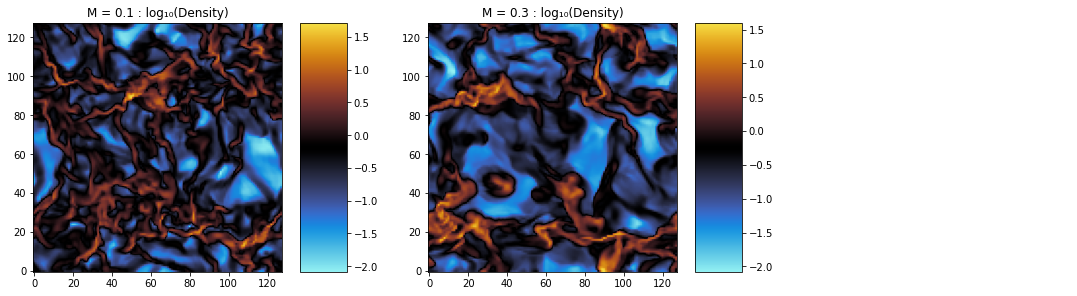

(128, 128, 128)


In [56]:
density_list = [rho_full_01, rho_full_03]
mach_labels = ['M = 0.1', 'M = 0.3']

# Optional: set consistent color scale
show_midplane_panel(density_list, mach_labels, field_name= "Density")

print(rho_full_01.shape)


this is log rho shape (128, 128, 128)
this is log rho shape (128, 128, 128)


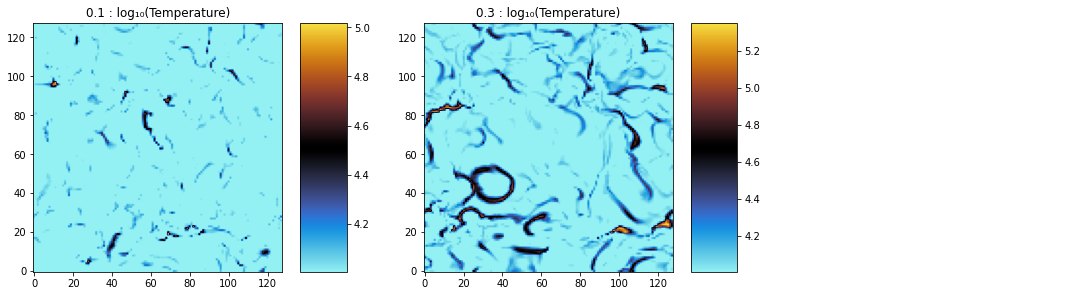

In [57]:
temp1 = [un.temperature(rho_full_01, prs_full_01), un.temperature(rho_full_03, prs_full_03)]
mach = [0.1, 0.3]
#temp1 = [un.temperature(rho_full_01, prs_full_01)]
#mach = [0.1]
show_midplane_panel(temp1, mach, field_name='Temperature')

# Distribution

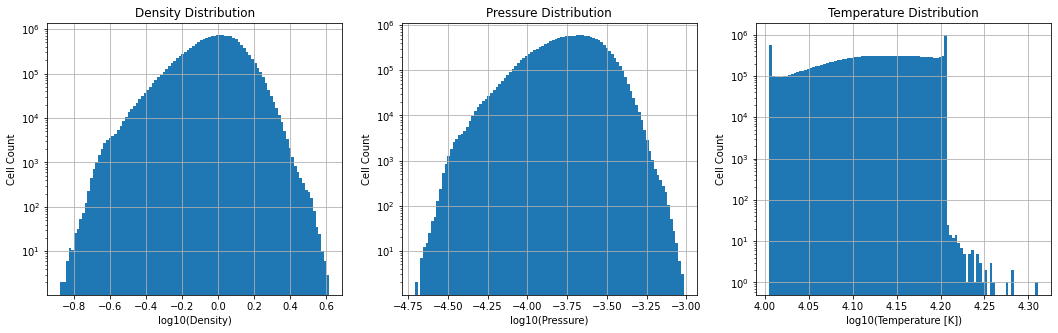

In [42]:
rho_flat = rho_full_01.flatten()
prs_flat = prs_full_01.flatten()

# Avoid division by zero
rho_safe = np.where(rho_flat == 0, 1e-20, rho_flat)
T_flat = (prs_flat / rho_safe) * (KELVIN * mu)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(np.log10(rho_safe), bins=100, log=True)
axs[0].set_xlabel("log10(Density)")
axs[0].set_ylabel("Cell Count")
axs[0].set_title("Density Distribution")
axs[0].grid(True)

prs_safe = np.where(prs_flat <= 0, 1e-20, prs_flat)
axs[1].hist(np.log10(prs_safe), bins=100, log=True)
axs[1].set_xlabel("log10(Pressure)")
axs[1].set_ylabel("Cell Count")
axs[1].set_title("Pressure Distribution")
axs[1].grid(True)


T_safe = np.where(T_flat <= 0, 1e-20, T_flat)
axs[2].hist(np.log10(T_safe), bins=100, log=True)
axs[2].set_xlabel("log10(Temperature [K])")
axs[2].set_ylabel("Cell Count")
axs[2].set_title("Temperature Distribution")
axs[2].grid(True)

In [ ]:
datasets = [
    #(rho_full_03, prs_full_03),
    (rho_full_01, prs_full_01),
    (rho_full_05, prs_full_05),
    (rho_full_09, prs_full_09)
]
labels = ["M = 0.5", "M = 0.75", "M = 0.9"]  # Update as appropriate

fig, axs = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

for i, (rho_full, prs_full) in enumerate(datasets):
    rho_flat = rho_full.flatten()
    prs_flat = prs_full.flatten()

    rho_safe = np.where(rho_flat <= 0, 1e-20, rho_flat)
    prs_safe = np.where(prs_flat <= 0, 1e-20, prs_flat)
    T_flat = (prs_safe / rho_safe) * (KELVIN * mu)
    T_safe = np.where(T_flat <= 0, 1e-20, T_flat)

    axs[i, 0].hist(np.log10(rho_safe), bins=100, log=True)
    axs[i, 0].set_xlabel("log₁₀(Density)")
    axs[i, 0].set_ylabel("Cell Count")
    axs[i, 0].set_title(f"{labels[i]} - Density")
    axs[i, 0].grid(True)

    axs[i, 1].hist(np.log10(prs_safe), bins=100, log=True)
    axs[i, 1].set_xlabel("log₁₀(Pressure)")
    axs[i, 1].set_ylabel("Cell Count")
    axs[i, 1].set_title(f"{labels[i]} - Pressure")
    axs[i, 1].grid(True)

    axs[i, 2].hist(np.log10(T_safe), bins=100, log=True)
    axs[i, 2].set_xlabel("log₁₀(Temperature) [K]")
    axs[i, 2].set_ylabel("Cell Count")
    axs[i, 2].set_title(f"{labels[i]} - Temperature")
    axs[i, 2].grid(True)

plt.suptitle("Distributions of Density, Pressure, and Temperature", fontsize=16)
plt.show()


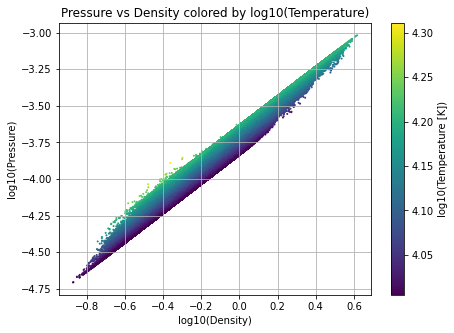

In [15]:
plt.figure(figsize=(7, 5))
rho_flat = rho_full_01.flatten()
prs_flat = prs_full_01.flatten()

# Avoid division by zero
rho_safe1 = np.where(rho_flat == 0, 1e-20, rho_flat)
prs_safe1 = np.where(prs_flat == 0, 1e-20, prs_flat)
T_flat1 = un.temperature(rho_flat, prs_flat)
T_safe1 = np.where(T_flat1 <= 0, 1e-20, T_flat1)
sc = plt.scatter(np.log10(rho_safe1), np.log10(prs_safe1), c=np.log10(T_safe1), s=1, cmap='viridis')
plt.xlabel("log10(Density)")
plt.ylabel("log10(Pressure)")
plt.title("Pressure vs Density colored by log10(Temperature)")
plt.colorbar(sc, label="log10(Temperature [K])")
plt.grid(True)
plt.show()

# Turbulent Velocity Comparison

In [15]:
print(vt_024)
print(vt_102)
print(vt_204)
print(vt_408)
print(vt_505)
print(vt_906)

#print(v_turb_09)


0.06020285284395705
0.06020285284395705
0.06020285284395705
0.06020285284395705
0.06020285284395705
0.06020285284395705


In [ ]:
v_turb_calc = np.sqrt(2* KE_01/mass_01)
t_eddy = 0.5/np.average(v_turb_calc[- 500 : ])
print("calculated v_turb = ", np.average(v_turb_calc[- 500 : ]))
print("v_turb from input file = ", v_turb_05)
print("Calculated t_eddy = ", t_eddy)

In [10]:
t_per_eddy = time_01/t_eddy

In [ ]:
plt.plot(t_per_eddy, v_turb_calc)
plt.xlabel('time (s)')
plt.ylabel('v_turb (m/s)')
plt.axhline(np.average(v_turb_calc[- 500 : ]), color='r', label='v_turb')
plt.axhline(v_turb_01, color='k', label='real v_turb')
plt.title('v_turb vs time')
plt.legend()
plt.grid(which='both', axis='both')
plt.show()

In [20]:
print("Avg v_turb (last 500):", np.average(v_turb_calc[-500:]))
print("Mean of entire series:", np.mean(v_turb_calc))
print("Final value:", v_turb_calc[-1])

Avg v_turb (last 500): 0.07695192693668361
Mean of entire series: 0.07320371512028635
Final value: 0.07355678078872131


# Evolution of Temperature
The variables are : time_0* , mass_0* , KE_0* , Etot_0*  

In [13]:
# Compute internal energy
Etherm = Etot_024 - KE_024
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass_024) * (KELVIN) * (2/3)
v_turb_calc = np.sqrt(2* KE_024/mass_024)
t_eddy = 0.5/np.average(v_turb_calc[- 500 : ])
t_per_eddy = time_024/t_eddy


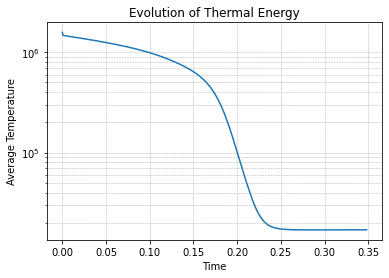

In [17]:
plt.plot(t_per_eddy - t_per_eddy[0] , avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Thermal Energy")
plt.grid(which='both', axis='both', linestyle='--', linewidth=0.5)
plt.show()


In [23]:
Etherm = Etot_05 - KE_05
epsilon = Etherm / mass_05
time = time_05
dedt = np.gradient(epsilon, time)
avg_dedt = np.mean(dedt[-500:])
print(f"Estimated global heating rate: {-avg_dedt:.5e}")
print(-0.5*(v_turb_05**3)*np.average(mass_01))

Estimated global heating rate: -1.02672e-03
-0.00023469226422291717


In [19]:
# Group your already-extracted arrays
time_all = [time_024, time_102]
mass_all = [mass_024, mass_102]
KE_all   = [KE_024,   KE_102]
Etot_all = [Etot_024, Etot_102]
tc_over_teddy = [0.24, 1.2]


9.28979861776288


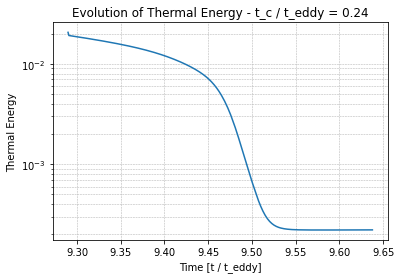

9.645816676453169


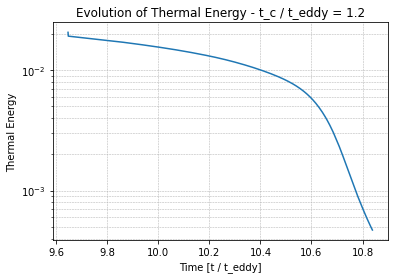

In [20]:

# Plot evolution of thermal energy for each simulation
for i in range(2):
    Etherm = Etot_all[i] - KE_all[i]
    avg_T = (Etherm / mass_all[i]) * KELVIN * (2/3)
    v_turb_calc = np.sqrt(2 * KE_all[i] / mass_all[i])
    t_eddy = 0.5 / np.average(v_turb_calc[-500:])
    t_per_eddy = time_all[i] / t_eddy

    plt.figure()
    print(min(t_per_eddy))
    plt.plot(t_per_eddy, Etherm)
    plt.yscale("log")
    plt.xlabel("Time [t / t_eddy]")
    plt.ylabel("Thermal Energy")
    plt.title(f"Evolution of Thermal Energy - t_c / t_eddy = {tc_over_teddy[i]}")
    plt.grid(which='both', axis='both', linestyle='--', linewidth=0.5)
    plt.show() 

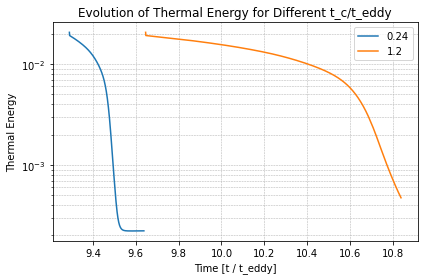

9.645816676453169


In [23]:
# Plot all on one figure
for i in range(2):
    Etherm = Etot_all[i] - KE_all[i]
    avg_T = (Etherm / mass_all[i]) * KELVIN * (2/3)
    
    v_turb_calc = np.sqrt(2 * KE_all[i] / mass_all[i])
    t_eddy = 0.5 / np.average(v_turb_calc[-500:])
    t_per_eddy = time_all[i] / t_eddy

    plt.plot(t_per_eddy, Etherm, label=tc_over_teddy[i])

# Finalize plot
plt.yscale("log")
plt.xlabel("Time [t / t_eddy]")
plt.ylabel("Thermal Energy")
plt.ylim()
plt.title("Evolution of Thermal Energy for Different t_c/t_eddy")
plt.legend()
plt.grid(which='both', axis='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(min(t_per_eddy))

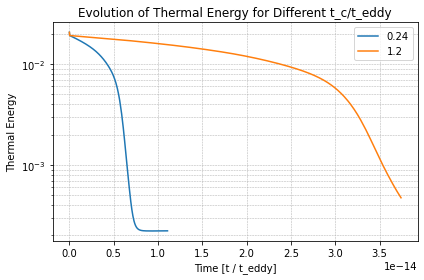

In [62]:
# Plot all on one figure
for i in range(2):
    # Compute thermal energy
    Etherm = Etot_all[i] - KE_all[i]
    avg_T = (Etherm / mass_all[i]) * KELVIN * (2/3)
    
    v_turb_calc = np.sqrt(2 * KE_all[i] / mass_all[i]) * un.unit_velocity  # in cm/s
    L_drive = 0.5 * unit_length  # in cm (if L_box=1 and k_peak=2)
    t_eddy = L_drive / np.mean(v_turb_calc)  # now in seconds

    t_per_eddy = time_all[i] / t_eddy
    t_per_eddy -= t_per_eddy[0]
    # Plot
    plt.plot(t_per_eddy, Etherm, label=f"{tc_over_teddy[i]}")

# Finalize plot
plt.yscale("log")
plt.xlabel("Time [t / t_eddy]")
plt.ylabel("Thermal Energy")
plt.title("Evolution of Thermal Energy for Different t_c/t_eddy")
plt.legend()
plt.grid(which='both', axis='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [40]:
# Compute internal energy
Etherm = Etot_024 - KE_024
avg_T = (Etherm / mass_024) * (KELVIN) * (2/3)
v_turb_calc = np.sqrt(2* KE_024/mass_024)
t_eddy = 0.5/np.average(v_turb_calc[- 500 : ])
t_per_eddy = time_024/t_eddy
print(t_per_eddy[0])
print(t_per_eddy[-1:])
print(f"t_eddy value: {t_eddy}")
print(f"time at 0 divided with calc t_eddy: {time_024[0]/8.305254259228818}")
print(f"start time: {time_024[0]} and end time : {time_024[-1]}")


9.513972921258558
[9.53085528]
t_eddy value: 6.983622987988355
time at 0 divided with calc t_eddy: 7.999995897316388
start time: 66.442 and end time : 66.5599


In [24]:
import numpy as np

# Your existing arrays
Etherm = Etot_01 - KE_01
epsilon = Etherm / mass_01
time = time_01

# Define rescaling time from input file
t_rescale = 6*t_eddy

# Mask only post-rescaling data
mask = time > t_rescale

# Apply mask
epsilon_post = epsilon[mask]
time_post = time[mask]

# Compute dε/dt only after rescaling
dedt_post = np.gradient(epsilon_post, time_post)
avg_dedt = np.mean(dedt_post[-500:])  # or fewer depending on length

print(f"Estimated global heating rate: {-avg_dedt:.5e}")


Estimated global heating rate: 3.03700e-08


# Tracers

In [5]:
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


In [6]:
filenames = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_01/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)] 
filenames_01 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_01/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)] 
filenames_05 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_05/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)] 
filenames_09 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_09/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)] 

rho_list = []

for i, filename in enumerate(filenames):
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    xs = tracers.x
    ys = tracers.y
    zs = tracers.z
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    rho_list.append(rho)


In [7]:

# Concatenate all frames' tracer density
all_rho = np.concatenate(rho_list)

print("Tracer density stats:")
print(f"Mean: {np.mean(all_rho):.3e}")
print(f"Std : {np.std(all_rho):.3e}")
print(f"Min : {np.min(all_rho):.3e}")
print(f"Max : {np.max(all_rho):.3e}")


Tracer density stats:
Mean: 1.086e+00
Std : 3.001e-01
Min : 1.093e-01
Max : 4.385e+00


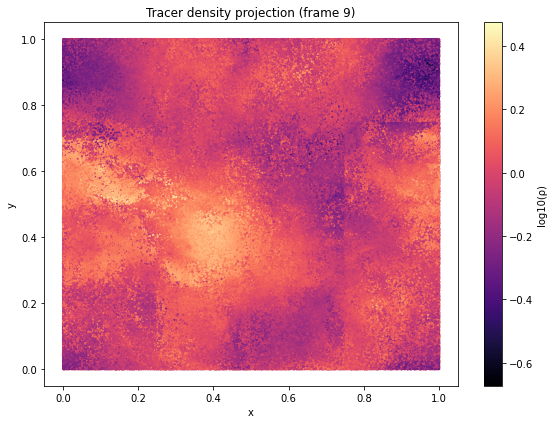

In [8]:

# Just take a single frame for now (e.g., frame 0)
frame = 9
data = phdf.phdf(filenames[frame])
tracers = data.GetSwarm("tracers")

x = tracers.x
y = tracers.y
rho = tracers.Get("rho")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=np.log10(rho), s=1, cmap='magma')
plt.colorbar(label='log10(ρ)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Tracer density projection (frame {frame})')
plt.tight_layout()
plt.show()


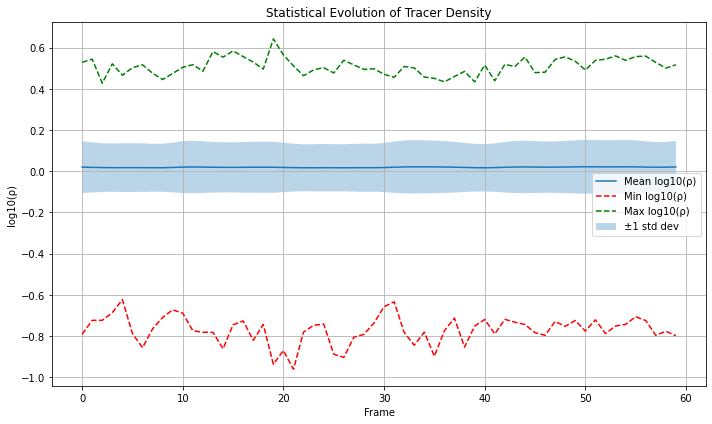

In [9]:
means = []
mins = []
maxs = []
stds = []

for rho in rho_list:
    log_rho = np.log10(rho)
    means.append(np.mean(log_rho))
    mins.append(np.min(log_rho))
    maxs.append(np.max(log_rho))
    stds.append(np.std(log_rho))

frames = np.arange(len(rho_list))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(frames, means, label='Mean log10(ρ)')
plt.fill_between(frames, np.array(means)-np.array(stds), np.array(means)+np.array(stds),
                 alpha=0.3, label='±1 std dev')
plt.plot(frames, mins, '--', label='Min log10(ρ)', color='red')
plt.plot(frames, maxs, '--', label='Max log10(ρ)', color='green')

plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Statistical Evolution of Tracer Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Selected tracer IDs: [2031247]


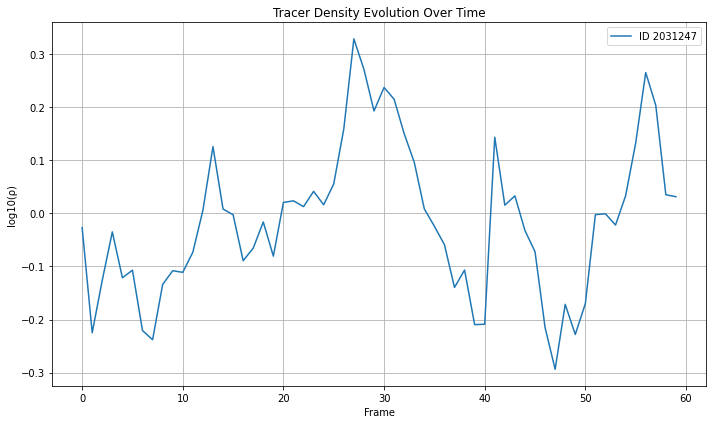

In [32]:
data0 = phdf.phdf(filenames[0])
tracers0 = data0.GetSwarm("tracers")
ids0 = tracers0.Get("id")

import numpy as np
selected_ids = np.random.choice(ids0, size=1, replace=False)
print("Selected tracer IDs:", selected_ids)

# Initialize storage
id_rho_dict = {tid: [] for tid in selected_ids}

for filename in filenames:
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    for tid in selected_ids:
        match = np.where(ids == tid)[0]
        if len(match) == 1:
            id_rho_dict[tid].append(np.log10(rho[match[0]]))  # log scale
        else:
            id_rho_dict[tid].append(np.nan)


plt.figure(figsize=(10, 6))
for tid, log_rhos in id_rho_dict.items():
    plt.plot(log_rhos, label=f'ID {tid}')
plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Tracer Density Evolution Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter

frame = 9
data = phdf.phdf(filenames[frame])
tracers = data.GetSwarm("tracers")

x_all = tracers.x
y_all = tracers.y
z_all = tracers.z
rho_all = tracers.Get("rho")

n_total = len(x_all)
n_sample = 10000  # number of particles to plot
idx = np.random.choice(n_total, min(n_sample, n_total), replace=False)

x = x_all[idx]
y = y_all[idx]
z = z_all[idx]
rho = rho_all[idx]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=np.log10(rho), s=1, cmap='magma')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'Tracer Density 3D (frame {frame})')
fig.colorbar(sc, ax=ax, label='log10(ρ)')

# Rotation function
def update(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Animate
n_frames = 90  # more frames = smoother
anim = FuncAnimation(fig, update, frames=np.linspace(0, 360, n_frames), blit=False)

anim.save("tracer_rotation.gif", writer=PillowWriter(fps=15))

plt.close()


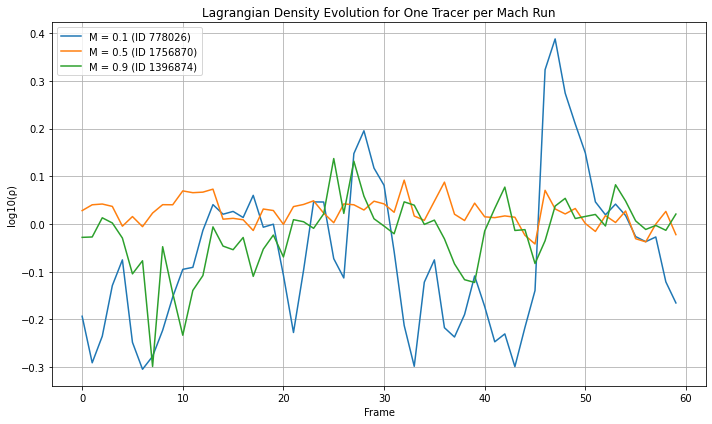

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from phdf import phdf  # Make sure this is correctly imported

# File lists
filenames_01 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_01/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)]
filenames_05 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_05/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)]
filenames_09 = [f"/ptmp/mpa/ankitad/athenapk/c-4_256_09/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(40, 100)]

def extract_logrho_for_random_tracer(filenames):
    data0 = phdf(filenames[0])
    tracers0 = data0.GetSwarm("tracers")
    ids0 = tracers0.Get("id")
    selected_id = np.random.choice(ids0, size=1, replace=False)[0]

    log_rho_values = []
    for filename in filenames:
        data = phdf(filename)
        tracers = data.GetSwarm("tracers")
        ids = tracers.Get("id")
        rho = tracers.Get("rho")
        match = np.where(ids == selected_id)[0]
        if len(match) == 1:
            log_rho_values.append(np.log10(rho[match[0]]))
        else:
            log_rho_values.append(np.nan)
    return selected_id, log_rho_values

# Extract data for one random tracer from each Mach run
id_01, logrho_01 = extract_logrho_for_random_tracer(filenames_01)
id_05, logrho_05 = extract_logrho_for_random_tracer(filenames_05)
id_09, logrho_09 = extract_logrho_for_random_tracer(filenames_09)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(logrho_01, label=f'M = 0.1 (ID {id_01})')
plt.plot(logrho_05, label=f'M = 0.5 (ID {id_05})')
plt.plot(logrho_09, label=f'M = 0.9 (ID {id_09})')
plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Lagrangian Density Evolution for One Tracer per Mach Run')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
import glob

# Adjust path pattern as needed
m01_file_pattern = "/ptmp/mpa/ankitad/athenapk/c-4_256_01/parthenon.prim.*.phdf"
m01_files = sorted(glob.glob(m01_file_pattern))  # sorted to ensure time order


In [25]:
rho_snapshots_01 = []
pres_snapshots_01 = []
for f in m01_files:
    rho_full, pres_full = read_hdf5(f)
    rho_snapshots_01.append(rho_full)
    pres_snapshots_01.append(pres_full)



Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 64, 64, 64)
RootGridSize = [256 256 256]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
Keys: <Key

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

def save_log_density_evolution_gif(rho_snapshots, output_path, slice_index=20, fps=5):
    images = []

    # Pre-compute global vmin/vmax for consistent color scale
    log_rho_all = [np.log10(np.where(r <= 0, 1e-20, r)) for r in rho_snapshots]
    vmin = min(np.min(r[:, :, slice_index]) for r in log_rho_all)
    vmax = max(np.max(r[:, :, slice_index]) for r in log_rho_all)

    for t, log_rho in enumerate(log_rho_all):
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(log_rho[:, :, slice_index], origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
        ax.set_title(f'M = 0.1 — log₁₀(Temperature) — t = {t}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Convert to image array
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        images.append(image)
        plt.close(fig)

    imageio.mimsave(output_path, images, fps=fps)
    print(f"GIF saved to {output_path}")


In [ ]:
temps = un.temperature(rho_full, pres_full)
temp_snapshots = []
temp_snapshots.append(temps)
log_T_all = [np.log10(np.where(T <= 0, 1e-20, T)) for T in temp_snapshots]
save_log_density_evolution_gif(rho_snapshots_01, "m0.1_log_temperature_evolution.gif", slice_index=20)

GIF saved to m0.1_log_density_evolution.gif


In [ ]:
rho_list = []

for filename in filenames:
    try:
        data = phdf.phdf(filename)
        tracers = data.GetSwarm("tracers")
        rho = tracers.Get("rho")
        rho_list.append(rho)
    except Exception as e:
        print(f"Skipped {filename}: {e}")

# Combine all tracer densities
all_rho = np.concatenate(rho_list)
all_rho_safe = np.where(all_rho <= 0, 1e-20, all_rho)
log_all_rho = np.log10(all_rho_safe)

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(log_all_rho, bins=100, color='steelblue')
plt.title("log₁₀(Tracer Density) — M=0.1")
plt.xlabel("log₁₀(ρ)")
plt.ylabel("Tracer Count")
plt.grid(True)
plt.tight_layout()
plt.show()